## 4. Preprocessing and Performance: Detecting Exoplanets

**Objective**: Utilize data from the **K2 Kepler mission** (which concluded in 2018) to develop a machine learning model that assists in classifying celestial bodies and determining their exoplanet status. An exoplanet is defined as "A planet that orbits a star outside the solar system".

**Background**: The Kepler Mission was strategically devised to survey a segment of the Milky Way galaxy. Its primary goal was to identify Earth-sized or smaller planets situated in or near the habitable zone. This would further help in estimating the fraction of stars in our galaxy that might host such planets (_Nasa.gov, 2018_). The assignment itself is based almost completely on a previous student project from MAL 2022 submitted by Pavel Balan and Alex Vasilianov.

**Data Source**: The dataset is provided by the NASA Exoplanet Archive, NASA Exoplanet Science Institute [here](https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=koi). There are several datasets available, all from differet periods, but we will use the __Cumulative KOI Data__ dataset.

The cumulative KOI (Kepler Objects of interest) table gathers information from the individual KOI activity tables that describe the current results of different searches of the Kepler light curves. The intent of the cumulative table is to provide the most accurate dispositions and stellar and planetary information for all KOIs in one place. All the information in this table has provenance in other KOI activity tables (_exoplanetarchive.ipac.caltech.edu, 2018_).

The data has been locally downloaded and saved as `exoplanet_dataset.csv`.


#### Overall Instructions
1. Explore the dataset to understand the features and their distributions.
2. Preprocess the data, handling any missing values, outliers, or other anomalies.
3. Choose appropriate machine learning algorithms for the classification task.
4. Train and validate your model, ensuring to avoid overfitting.
5. Evaluate the model's performance using relevant metrics.

Below some guidelines are given but the assignment is relatively "free".

Best of luck with your analysis!


### 1. Explore

In [618]:
# Loading the data (change this if you want other var-names, etc.)
import pandas as pd

exoplanet_df = pd.read_csv('exoplanet_dataset.csv')

print(exoplanet_df.shape, "- 9564 rows with 49 features")

pd.set_option('display.max_columns', None)
exoplanet_df.head()

(9564, 49) - 9564 rows with 49 features


,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_impact,koi_impact_err1,koi_impact_err2,koi_duration,koi_duration_err1,koi_duration_err2,koi_depth,koi_depth_err1,koi_depth_err2,koi_prad,koi_prad_err1,koi_prad_err2,koi_teq,koi_teq_err1,koi_teq_err2,koi_insol,koi_insol_err1,koi_insol_err2,koi_model_snr,koi_tce_plnt_num,koi_tce_delivname,koi_steff,koi_steff_err1,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,9.488036,2.775000e-05,-2.775000e-05,170.538750,0.002160,-0.002160,0.146,0.318,-0.146,2.95750,0.08190,-0.08190,615.8,19.5,-19.5,2.26,0.26,-0.15,793.0,NaN,NaN,93.59,29.45,-16.65,35.8,1.0,q1_q17_dr25_tce,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,54.418383,2.479000e-04,-2.479000e-04,162.513840,0.003520,-0.003520,0.586,0.059,-0.443,4.50700,0.11600,-0.11600,874.8,35.5,-35.5,2.83,0.32,-0.19,443.0,NaN,NaN,9.11,2.87,-1.62,25.8,2.0,q1_q17_dr25_tce,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.000,0,0,0,0,19.899140,1.494000e-05,-1.494000e-05,175.850252,0.000581,-0.000581,0.969,5.126,-0.077,1.78220,0.03410,-0.03410,10829.0,171.0,-171.0,14.60,3.92,-1.31,638.0,NaN,NaN,39.30,31.04,-10.49,76.3,1.0,q1_q17_dr25_tce,5853.0,158.0,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,1.736952,2.630000e-07,-2.630000e-07,170.307565,0.000115,-0.000115,1.276,0.115,-0.092,2.40641,0.00537,-0.00537,8079.2,12.8,-12.8,33.46,8.50,-2.83,1395.0,NaN,NaN,891.96,668.95,-230.35,505.6,1.0,q1_q17_dr25_tce,5805.0,157.0,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,2.525592,3.761000e-06,-3.761000e-06,171.595550,0.001130,-0.001130,0.701,0.235,-0.478,1.65450,0.04200,-0.04200,603.3,16.9,-16.9,2.75,0.88,-0.35,1406.0,NaN,NaN,926.16,874.33,-314.24,40.9,1.0,q1_q17_dr25_tce,6031.0,169.0,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


**COLUMN NAME | COLUMN DESCRIPTION [Data measurement unit type]**

COLUMN kepid:          KepID <br/>
COLUMN kepoi_name:     KOI Name <br/>
COLUMN kepler_name:    Kepler Name <br/>
COLUMN koi_disposition: Exoplanet Archive Disposition <br/>
COLUMN koi_pdisposition: Disposition Using Kepler Data <br/>
COLUMN koi_score:      Disposition Score <br/>
COLUMN koi_fpflag_nt:  Not Transit-Like False Positive Flag <br/>
COLUMN koi_fpflag_ss:  Stellar Eclipse False Positive Flag <br/>
COLUMN koi_fpflag_co:  Centroid Offset False Positive Flag <br/>
COLUMN koi_fpflag_ec:  Ephemeris Match Indicates Contamination False Positive Flag <br/>
COLUMN koi_period:     Orbital Period [days] <br/>
COLUMN koi_period_err1: Orbital Period Upper Unc. [days] <br/>
COLUMN koi_period_err2: Orbital Period Lower Unc. [days] <br/>
COLUMN koi_time0bk:    Transit Epoch [BKJD] <br/>
COLUMN koi_time0bk_err1: Transit Epoch Upper Unc. [BKJD] <br/>
COLUMN koi_time0bk_err2: Transit Epoch Lower Unc. [BKJD] <br/>
COLUMN koi_impact:     Impact Parameter <br/>
COLUMN koi_impact_err1: Impact Parameter Upper Unc. <br/>
COLUMN koi_impact_err2: Impact Parameter Lower Unc. <br/>
COLUMN koi_duration:   Transit Duration [hrs] <br/>
COLUMN koi_duration_err1: Transit Duration Upper Unc. [hrs] <br/>
COLUMN koi_duration_err2: Transit Duration Lower Unc. [hrs] <br/>
COLUMN koi_depth:      Transit Depth [ppm] <br/>
COLUMN koi_depth_err1: Transit Depth Upper Unc. [ppm] <br/>
COLUMN koi_depth_err2: Transit Depth Lower Unc. [ppm] <br/>
COLUMN koi_prad:       Planetary Radius [Earth radii] <br/>
COLUMN koi_prad_err1:  Planetary Radius Upper Unc. [Earth radii] <br/>
COLUMN koi_prad_err2:  Planetary Radius Lower Unc. [Earth radii] <br/>
COLUMN koi_teq:        Equilibrium Temperature [K] <br/>
COLUMN koi_teq_err1:   Equilibrium Temperature Upper Unc. [K] <br/>
COLUMN koi_teq_err2:   Equilibrium Temperature Lower Unc. [K] <br/>
COLUMN koi_insol:      Insolation Flux [Earth flux] <br/>
COLUMN koi_insol_err1: Insolation Flux Upper Unc. [Earth flux] <br/>
COLUMN koi_insol_err2: Insolation Flux Lower Unc. [Earth flux] <br/>
COLUMN koi_model_snr:  Transit Signal-to-Noise <br/>
COLUMN koi_tce_plnt_num: TCE Planet Number <br/>
COLUMN koi_tce_delivname: TCE Delivery <br/>
COLUMN koi_steff:      Stellar Effective Temperature [K] <br/>
COLUMN koi_steff_err1: Stellar Effective Temperature Upper Unc. [K] <br/>
COLUMN koi_steff_err2: Stellar Effective Temperature Lower Unc. [K] <br/>
COLUMN koi_slogg:      Stellar Surface Gravity [log10(cm/s^2)] <br/>
COLUMN koi_slogg_err1: Stellar Surface Gravity Lower Unc. [log10(cm/s^2)] <br/>
COLUMN koi_slogg_err2: Stellar Surface Gravity Lower Unc. [log10(cm/s^2)] <br/>
COLUMN koi_srad:       Stellar Radius [Solar radii] <br/>
COLUMN koi_srad_err1:  Stellar Radius Upper Unc. [Solar radii] <br/>
COLUMN koi_srad_err2:  Stellar Radius Lower Unc. [Solar radii] <br/>
COLUMN ra:             RA [decimal degrees] <br/>
COLUMN dec:            Dec [decimal degrees] <br/>
COLUMN koi_kepmag:     Kepler-band [mag] <br/>

In [619]:
# For an easier comprehension, we will rename the columns into their description.

exoplanet_df = exoplanet_df.rename(columns={'kepid':'KepID',
'kepoi_name':'KOIName',
'kepler_name':'KeplerName',
'koi_disposition':'ExoplanetArchiveDisposition',
'koi_pdisposition':'DispositionUsingKeplerData',
'koi_score':'DispositionScore',
'koi_fpflag_nt':'NotTransit-LikeFalsePositiveFlag',
'koi_fpflag_ss':'koi_fpflag_ss',
'koi_fpflag_co':'CentroidOffsetFalsePositiveFlag',
'koi_fpflag_ec':'EphemerisMatchIndicatesContaminationFalsePositiveFlag',
'koi_period':'OrbitalPeriod, days',
'koi_period_err1':'OrbitalPeriodUpperUnc, days',
'koi_period_err2':'OrbitalPeriodLowerUnc, days',
'koi_time0bk':'TransitEpoch, BKJD',
'koi_time0bk_err1':'TransitEpochUpperUnc, BKJD',
'koi_time0bk_err2':'TransitEpochLowerUnc, BKJD',
'koi_impact':'ImpactParamete',
'koi_impact_err1':'ImpactParameterUpperUnc',
'koi_impact_err2':'ImpactParameterLowerUnc',
'koi_duration':'TransitDuration, hrs',
'koi_duration_err1':'TransitDurationUpperUnc, hrs',
'koi_duration_err2':'TransitDurationLowerUnc, hrs',
'koi_depth':'TransitDepth, ppm',
'koi_insol':'InsolationFlux, Earthflux',
'koi_insol_err1':'InsolationFluxUpperUnc, Earthflux',
'koi_insol_err2':'InsolationFluxLowerUnc, Earthflux',
'koi_model_snr':'TransitSignal-to-Noise',
'koi_tce_plnt_num':'TCEPlanetNumber',
'koi_tce_delivname':'TCEDeliver',
'koi_steff':'StellarEffectiveTemperature, K',
'koi_steff_err1':'StellarEffectiveTemperatureUpperUnc, K',
'koi_steff_err2':'StellarEffectiveTemperatureLowerUnc, K',
'koi_depth_err1':'TransitDepthUpperUnc, ppm',
'koi_depth_err2':'TransitDepthLowerUnc, ppm',
'koi_prad':'PlanetaryRadius, Earthradii',
'koi_prad_err1':'PlanetaryRadiusUpperUnc, Earthradii',
'koi_prad_err2':'PlanetaryRadiusLowerUnc, Earthradii',
'koi_teq':'EquilibriumTemperature, K',
'koi_teq_err1':'EquilibriumTemperatureUpperUnc, K',
'koi_teq_err2':'EquilibriumTemperatureLowerUnc, K',
'koi_slogg':'StellarSurfaceGravity, log10(cm/s^2)',
'koi_slogg_err1':'StellarSurfaceGravityUpperUnc, log10(cm/s^2)',
'koi_slogg_err2':'StellarSurfaceGravityLowerUnc, log10(cm/s^2)',
'koi_srad':'StellarRadius, Solarradii',
'koi_srad_err1':'StellarRadiusUpperUnc, Solarradii',
'koi_srad_err2':'StellarRadiusLowerUnc, Solarradii',
'ra':'RA, decimaldegrees',
'dec':'Dec, decimaldegrees',
'koi_kepmag':'Kepler-band, mag'
})

**Updated data type value analysis**

In [620]:
exoplanet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 49 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   KepID                                                  9564 non-null   int64  
 1   KOIName                                                9564 non-null   object 
 2   KeplerName                                             2673 non-null   object 
 3   ExoplanetArchiveDisposition                            9564 non-null   object 
 4   DispositionUsingKeplerData                             9564 non-null   object 
 5   DispositionScore                                       8054 non-null   float64
 6   NotTransit-LikeFalsePositiveFlag                       9564 non-null   int64  
 7   koi_fpflag_ss                                          9564 non-null   int64  
 8   CentroidOffsetFalsePositiveFlag                 

#### Description of some of the features

Given that some of the features might not be as straightforward going by their names, here are some descriptions for some of them, taken from the [Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/docs/API_kepcandidate_columns.html).

`DispositionScore` - A value between 0 and 1 that indicates the confidence in the KOI disposition. For CANDIDATEs, a higher value indicates more confidence in its disposition, while for FALSE POSITIVEs, a higher value indicates less confidence in that disposition. The value is calculated from a Monte Carlo technique such that the score's value is equivalent to the fraction of iterations where the Robovetter yields a disposition of CANDIDATE.

`NotTransit-LikeFlag` A KOI whose light curve is not consistent with that of a transiting planet. This includes, but is not limited to, instrumental artifacts, non-eclipsing variable stars, and spurious (very low SNR) detections.	

`StellarEclipseFlag` A KOI that is observed to have a significant secondary event, transit shape, or out-of-eclipse variability, which indicates that the transit-like event is most likely caused by an eclipsing binary. However, self-luminous, hot Jupiters with a visible secondary eclipse will also have this flag set, but with a disposition of PC.

`Centroid Offset Flag` The source of the signal is from a nearby star, as inferred by measuring the centroid location of the image both in and out of transit, or by the strength of the transit signal in the target's outer (halo) pixels as compared to the transit signal from the pixels in the optimal (or core) aperture.

`EphemerisMatchIndicatesContaminationFlag` The KOI shares the same period and epoch as another object and is judged to be the result of flux contamination in the aperture or electronic crosstalk.

`Upper/LowerUnc` Uncertainties Columns(positive +)(negative -) aka - the error range for the columns. 

`TransitEpoch`	The time corresponding to the center of the first detected transit in Barycentric Julian Day (BJD).

`ImpactParameter`	The sky-projected distance between the center of the stellar disc and the center of the planet disc at conjunction, normalized by the stellar radius.

`TransitDepth` (parts per million)	The fraction of stellar flux lost at the minimum of the planetary transit. Transit depths are typically computed from a best-fit model produced by a Mandel-Agol (2002) model fit to a multi-quarter Kepler light curve, assuming a linear orbital ephemeris.

`InsolationFlux` [Earth flux]	Insolation flux is another way to give the equilibrium temperature. It depends on the stellar parameters (specifically the stellar radius and temperature), and on the semi-major axis of the planet. It's given in units relative to those measured for the Earth from the Sun.

`Equilibrium Temperature` (Kelvin)	Approximation for the temperature of the planet. The calculation of equilibrium temperature assumes a) thermodynamic equilibrium between the incident stellar flux and the radiated heat from the planet, b) a Bond albedo (the fraction of total power incident upon the planet scattered back into space) of 0.3, c) the planet and star are blackbodies, and d) the heat is evenly distributed between the day and night sides of the planet.

`RA` Right ascension (abbreviated RA; symbol α) is the angular distance of a particular point measured eastward along the celestial equator from the Sun at the March equinox to the (hour circle of the) point in question above the earth.

`Dec` declination (abbreviated dec; symbol δ) is one of the two angles that locate a point on the celestial sphere in the equatorial coordinate system, the other being hour angle. 

#### Target identification and modelling

Because this problem uses a supervised approach, we can determine the labels from the dataframe.
We have the columns `DispositionUsingKeplerData` and `ExoplanetArchiveDisposition`. The first one holds values of either 'CANDIDATE' or 'FALSE POSITIVE'. The second one - 'CONFRIMED', 'CANDIDATE' or 'FALSE POSITIVE'. We will use `DispositionUsingKeplerData` as our only label, as we will be searching only for candidates. `ExoplanetArchiveDisposition` will still be used for data visualization however.

DispositionUsingKeplerData
FALSE POSITIVE    4847
CANDIDATE         4717
Name: count, dtype: int64


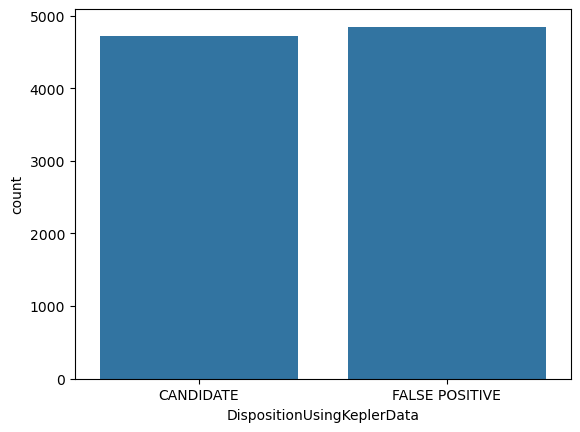

In [621]:
import seaborn as sns
sns.countplot(x = exoplanet_df['DispositionUsingKeplerData'])
print(exoplanet_df['DispositionUsingKeplerData'].value_counts())

ExoplanetArchiveDisposition
FALSE POSITIVE    4839
CONFIRMED         2671
CANDIDATE         2054
Name: count, dtype: int64


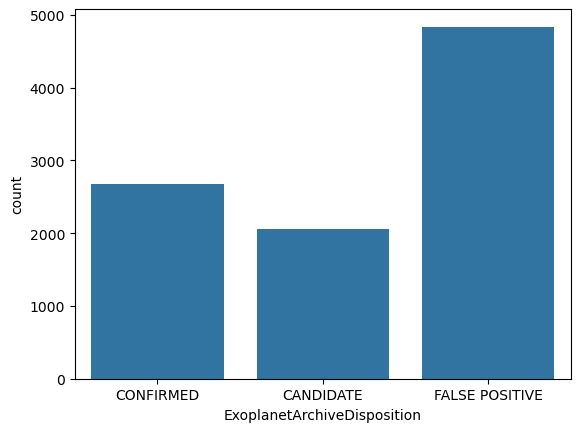

In [622]:
sns.countplot(x= exoplanet_df['ExoplanetArchiveDisposition'])
print(exoplanet_df['ExoplanetArchiveDisposition'].value_counts())

#### Tasks

-  Explore missing values by finding the the precentage of missing values for each column - print as a dataframe
-  Visualise the missing values of the columns with the 5 most percentage of missing value
-  Identify potential outliers of the numeric features. This can be done in many ways but you should probably try to write some kind of script/loop that will iterate through the features and calculate the number of values outside [Q1 - 1.5IQR ; Q3 + 1.5IQR]. Don't remove them just yet but discuss what could be a good approach.
-  Determine what to do with potential outlier: keep, replace or remove

In [623]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Task 1.1: *Explore missing values by finding the the precentage of missing values for each column - print as a dataframe*

In [624]:
# check the nulls column counts as sum
exoplanet_df.isnull().sum()

KepID                                                       0
KOIName                                                     0
KeplerName                                               6891
ExoplanetArchiveDisposition                                 0
DispositionUsingKeplerData                                  0
DispositionScore                                         1510
NotTransit-LikeFalsePositiveFlag                            0
koi_fpflag_ss                                               0
CentroidOffsetFalsePositiveFlag                             0
EphemerisMatchIndicatesContaminationFalsePositiveFlag       0
OrbitalPeriod, days                                         0
OrbitalPeriodUpperUnc, days                               454
OrbitalPeriodLowerUnc, days                               454
TransitEpoch, BKJD                                          0
TransitEpochUpperUnc, BKJD                                454
TransitEpochLowerUnc, BKJD                                454
ImpactPa

In [625]:
# Select only the numeric columns (ignores strings/objects)
numeric_dataframe = exoplanet_df.select_dtypes(include=[np.number])

# Keep columns where the unique values are NOT just 0 and/or 1
# Drop NaNs temporarily for the check so they don't interfere
continuous_cols = [
    col for col in numeric_dataframe.columns 
    if not set(numeric_dataframe[col].unique()).issubset({0, 1})
]

missing_percentage = numeric_dataframe[continuous_cols].isnull().mean() * 100
missing_dataframe = pd.DataFrame(missing_percentage, columns=['missing_percentage'])
missing_dataframe_sorted = missing_dataframe.sort_values(by='missing_percentage', ascending=False)
missing_dataframe_sorted.head(5)


,missing_percentage
"EquilibriumTemperatureLowerUnc, K",100.000000
"EquilibriumTemperatureUpperUnc, K",100.000000
DispositionScore,15.788373
"StellarEffectiveTemperatureLowerUnc, K",5.050188
"StellarSurfaceGravityLowerUnc, log10(cm/s^2)",4.893350


In [626]:
# Check the unique values in the columns with high missing percentages

print("Lower Unc unique values:", exoplanet_df['EquilibriumTemperatureLowerUnc, K'].unique())
print("Upper Unc unique values:", exoplanet_df['EquilibriumTemperatureUpperUnc, K'].unique())

Lower Unc unique values: [nan]
Upper Unc unique values: [nan]


In [627]:
# if .info() shows 0 non-null values, it means these columns are entirely empty
# which mean we can drop them without losing any data, as they don't contain any valid entries.

exoplanet_df['EquilibriumTemperatureLowerUnc, K'].info()
print("\n")
exoplanet_df['EquilibriumTemperatureUpperUnc, K'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 9564 entries, 0 to 9563
Series name: EquilibriumTemperatureLowerUnc, K
Non-Null Count  Dtype  
--------------  -----  
0 non-null      float64
dtypes: float64(1)
memory usage: 74.8 KB


<class 'pandas.core.series.Series'>
RangeIndex: 9564 entries, 0 to 9563
Series name: EquilibriumTemperatureUpperUnc, K
Non-Null Count  Dtype  
--------------  -----  
0 non-null      float64
dtypes: float64(1)
memory usage: 74.8 KB


In [628]:
# it's confirmed that these columns are entirely empty, so we can safely drop them without losing any data.
exoplanet_df = exoplanet_df.drop(columns=['EquilibriumTemperatureLowerUnc, K', 'EquilibriumTemperatureUpperUnc, K'])

In [629]:
# check again
# Select only the numeric columns (ignores strings/objects)
numeric_dataframe = exoplanet_df.select_dtypes(include=[np.number])

# Keep columns where the unique values are NOT just 0 and/or 1
# Drop NaNs temporarily for the check so they don't interfere
continuous_cols = [
    col for col in numeric_dataframe.columns 
    if not set(numeric_dataframe[col].unique()).issubset({0, 1})
]

missing_percentage = numeric_dataframe[continuous_cols].isnull().mean() * 100
missing_dataframe = pd.DataFrame(missing_percentage, columns=['missing_percentage'])
missing_dataframe_sorted = missing_dataframe.sort_values(by='missing_percentage', ascending=False)
missing_dataframe_sorted

,missing_percentage
DispositionScore,15.788373
"StellarEffectiveTemperatureLowerUnc, K",5.050188
"StellarEffectiveTemperatureUpperUnc, K",4.893350
"StellarRadiusLowerUnc, Solarradii",4.893350
"StellarRadiusUpperUnc, Solarradii",4.893350
"StellarSurfaceGravityUpperUnc, log10(cm/s^2)",4.893350
"StellarSurfaceGravityLowerUnc, log10(cm/s^2)",4.893350
ImpactParameterLowerUnc,4.746968
"TransitDepthUpperUnc, ppm",4.746968
"TransitDurationLowerUnc, hrs",4.746968


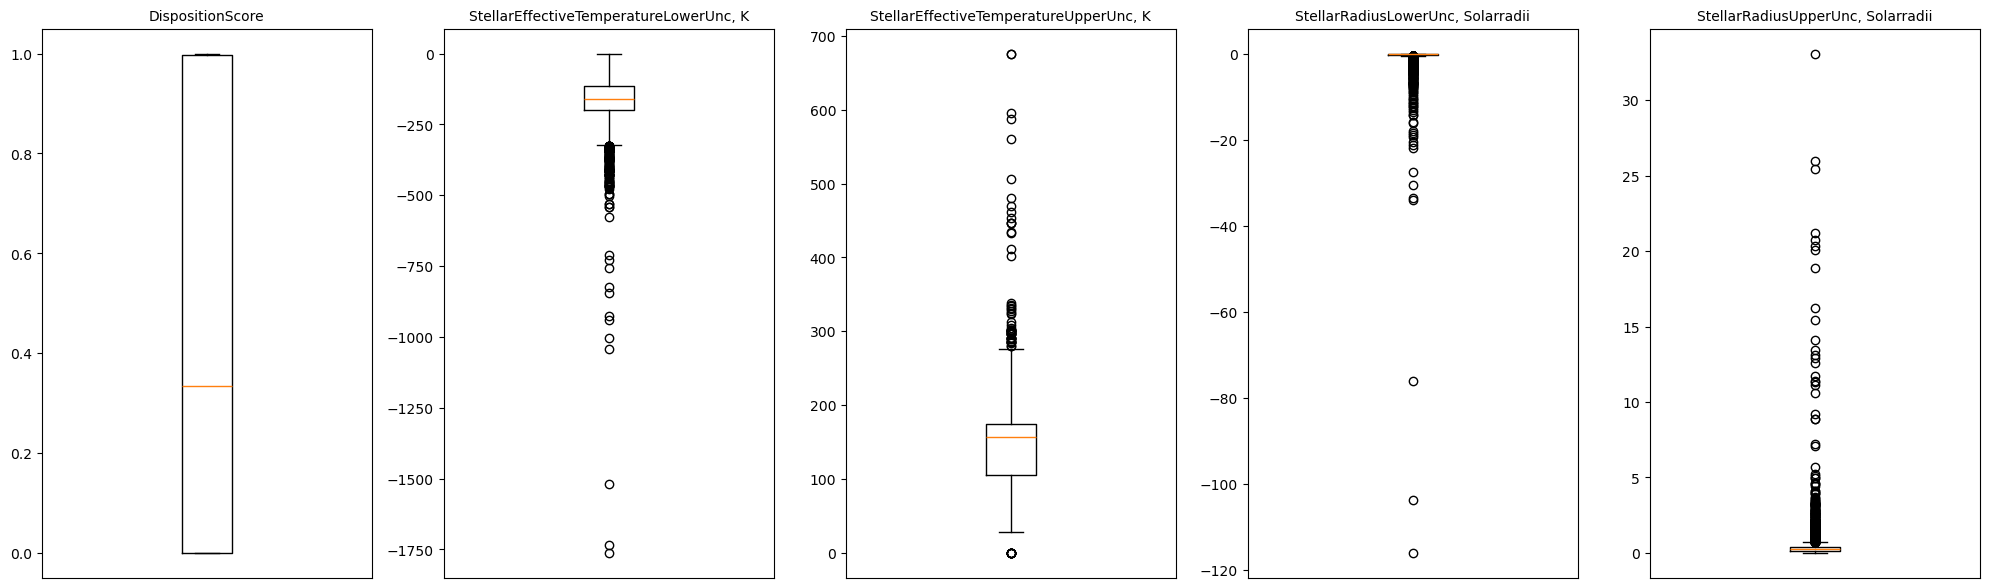

In [630]:
# List the 5 columns you want to check for outliers
columns_to_plot = [
    'DispositionScore',
    'StellarEffectiveTemperatureLowerUnc, K',
    'StellarEffectiveTemperatureUpperUnc, K',
    'StellarRadiusLowerUnc, Solarradii',
    'StellarRadiusUpperUnc, Solarradii'
]

# Create a figure with 1 row and 5 separate subplot areas
# figsize=(20, 6) makes the figure wide enough to fit all 5 plots nicely
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 6))

# Loop through the columns and the axes to create each boxplot
for i, col in enumerate(columns_to_plot):
    # .dropna() is required for boxplot to work
    axes[i].boxplot(exoplanet_df[col].dropna())
    
    # Set the title for each subplot to the column name
    axes[i].set_title(col, fontsize=10)
    
    # Remove x-axis tick marks since it's just a single boxplot per charting area
    axes[i].set_xticks([]) 

# Automatically adjust the spacing so titles and labels don't overlap
plt.tight_layout()
plt.show()


I feels like there's more than 5 columns that have big outliers


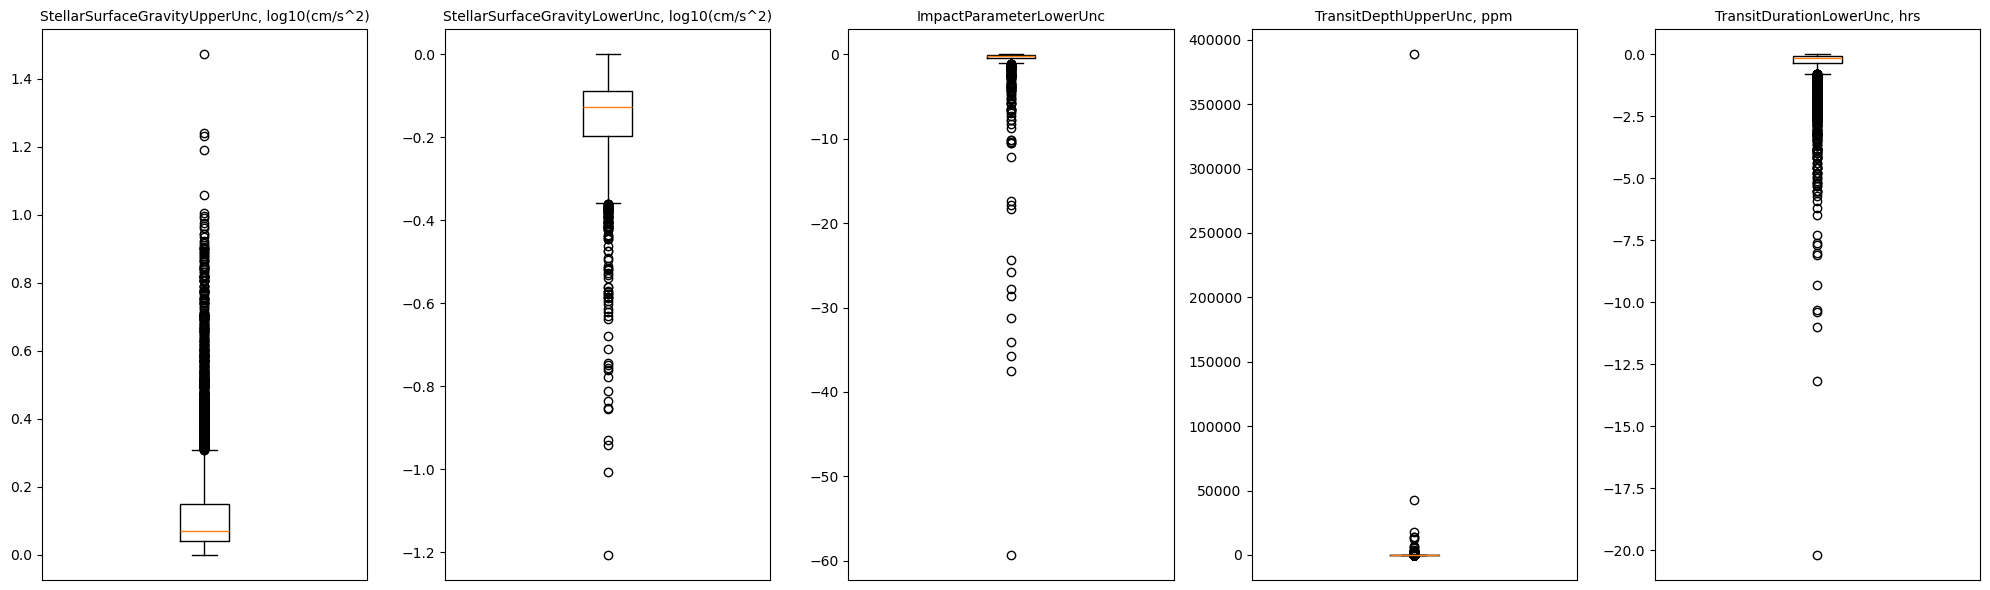

In [631]:
# List the 5 columns you want to check for outliers
columns_to_plot = [
    'StellarSurfaceGravityUpperUnc, log10(cm/s^2)',
    'StellarSurfaceGravityLowerUnc, log10(cm/s^2)',
    'ImpactParameterLowerUnc',
    'TransitDepthUpperUnc, ppm',
    'TransitDurationLowerUnc, hrs'
]

# Create a figure with 1 row and 5 separate subplot areas
# figsize=(20, 6) makes the figure wide enough to fit all 5 plots nicely
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 6))

# Loop through the columns and the axes to create each boxplot
for i, col in enumerate(columns_to_plot):
    # .dropna() is required for boxplot to work
    axes[i].boxplot(exoplanet_df[col].dropna())
    
    # Set the title for each subplot to the column name
    axes[i].set_title(col, fontsize=10)
    
    # Remove x-axis tick marks since it's just a single boxplot per charting area
    axes[i].set_xticks([]) 

# Automatically adjust the spacing so titles and labels don't overlap
plt.tight_layout()
plt.show()

In [632]:
skew_values = exoplanet_df[continuous_cols].skew()
print(skew_values.sort_values(ascending=False))

NotTransit-LikeFalsePositiveFlag                96.930193
OrbitalPeriod, days                             96.459326
TransitDepthUpperUnc, ppm                       92.693639
PlanetaryRadius, Earthradii                     52.118954
InsolationFlux, Earthflux                       49.947777
InsolationFluxUpperUnc, Earthflux               42.902621
PlanetaryRadiusUpperUnc, Earthradii             40.588184
ImpactParamete                                  23.505943
StellarRadius, Solarradii                       20.947097
StellarRadiusUpperUnc, Solarradii               18.630659
TransitEpochUpperUnc, BKJD                      11.166367
OrbitalPeriodUpperUnc, days                      8.516557
TransitDurationUpperUnc, hrs                     8.295464
ImpactParameterUpperUnc                          6.341046
TransitDuration, hrs                             5.928765
TransitSignal-to-Noise                           5.307083
TransitDepth, ppm                                5.260652
TransitEpoch, 

Use IQR to check the outlier counts, if it's a lot, we transform those, else remove the outlier.

In [633]:
# Create a dictionary to store the results
outlier_counts = {}

for col in continuous_cols:
    Q1 = exoplanet_df[col].quantile(0.25)
    Q3 = exoplanet_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count how many values fall outside the bounds
    # We use sum() because the condition returns booleans (True=1, False=0)
    outliers = ((exoplanet_df[col] < lower_bound) | (exoplanet_df[col] > upper_bound)).sum()
    
    outlier_counts[col] = outliers

# Convert to DataFrame for easy viewing
outlier_df = pd.DataFrame(list(outlier_counts.items()), columns=['Feature', 'Outlier_Count'])
outlier_df = outlier_df.sort_values(by='Outlier_Count', ascending=False)

# Display the result
outlier_df

,Feature,Outlier_Count
15,"TransitDepth, ppm",1798
19,"PlanetaryRadiusUpperUnc, Earthradii",1716
4,"OrbitalPeriodUpperUnc, days",1650
5,"OrbitalPeriodLowerUnc, days",1650
25,TransitSignal-to-Noise,1600
3,"OrbitalPeriod, days",1567
23,"InsolationFluxUpperUnc, Earthflux",1536
2,NotTransit-LikeFalsePositiveFlag,1531
24,"InsolationFluxLowerUnc, Earthflux",1483
26,TCEPlanetNumber,1473


idk why `NotTransit-LikeFalsePositiveFlag` is not here, let's check the other way

In [634]:
# Check unique values for any column that indicates a Flag (usually is boolean or categorical).
flag_cols = [col for col in exoplanet_df.columns if 'Flag' in col or 'Disposition' in col]

for col in flag_cols:
    unique_vals = exoplanet_df[col].dropna().unique()
    print(f"{col}: {unique_vals}")

ExoplanetArchiveDisposition: ['CONFIRMED' 'CANDIDATE' 'FALSE POSITIVE']
DispositionUsingKeplerData: ['CANDIDATE' 'FALSE POSITIVE']
DispositionScore: [1.    0.969 0.    0.992 0.811 0.998 0.98  0.971 0.978 0.014 0.999 0.993
 0.871 0.773 0.989 0.952 0.994 0.053 0.95  0.745 0.99  0.995 0.037 0.006
 0.996 0.997 0.878 0.876 0.985 0.942 0.912 0.974 0.959 0.987 0.983 0.573
 0.986 0.635 0.966 0.415 0.228 0.957 0.92  0.973 0.975 0.953 0.704 0.949
 0.965 0.632 0.752 0.945 0.765 0.815 0.931 0.711 0.881 0.758 0.001 0.848
 0.884 0.557 0.008 0.976 0.829 0.991 0.046 0.964 0.762 0.695 0.821 0.913
 0.982 0.968 0.934 0.894 0.875 0.885 0.961 0.729 0.921 0.907 0.545 0.098
 0.91  0.857 0.483 0.939 0.754 0.68  0.436 0.117 0.96  0.002 0.677 0.49
 0.041 0.988 0.005 0.085 0.979 0.909 0.383 0.867 0.927 0.087 0.936 0.896
 0.808 0.935 0.981 0.285 0.003 0.565 0.933 0.086 0.242 0.984 0.855 0.82
 0.748 0.944 0.464 0.809 0.938 0.977 0.802 0.889 0.972 0.406 0.004 0.956
 0.924 0.488 0.903 0.365 0.761 0.759 0.693 0.922 0

In [649]:
# Filter out the row(s) where the flag is 465
# Verify it was removed
print(exoplanet_df['NotTransit-LikeFalsePositiveFlag'].unique())
exoplanet_df = exoplanet_df[exoplanet_df['NotTransit-LikeFalsePositiveFlag'] != 465]

# Verify it was removed
print(exoplanet_df['NotTransit-LikeFalsePositiveFlag'].unique())

[0 1]
[0 1]


### 2. Feature Engineering

#### Tasks

-  Based only on the analysis above, you should be able to remove some columns (two of the columns will have 100% missing values). Remove these columns.
-  Filter out (i.e. remove) any irrelevant columns (e.g. names, IDs, etc.) - there should be 4
-  Remove rows with missing values, NaNs, nulls and/or infinite values - if you want, you may choose to impute instead
-  If you you chose to remove or replace outliers do this now. If you chose to keep, move on
-  Create a correlation matrix and discuss (use only numeric columns, perhaps make an extra dataset just with numeric values) - drop appropriate columns
-  The values of `ExoplanetArchiveDisposition` and `ExoplanetArchiveDisposition` are categorical and if they are to act like labels, you should change them. Change them as follows: 'FALSE POSITIVE' values is assigned a numerical value of `0`, 'CANDIDATE' assigned `1`, and 'CONFIRMED' a `2`. Same assignment in both features. The easiest way is to create two new features, call them `KeplerDispositionStatus` and `ArchiveDispositionStatus`, and then drop the originalæ features. It will look something like this (the last couple of columns in the new dataframe):

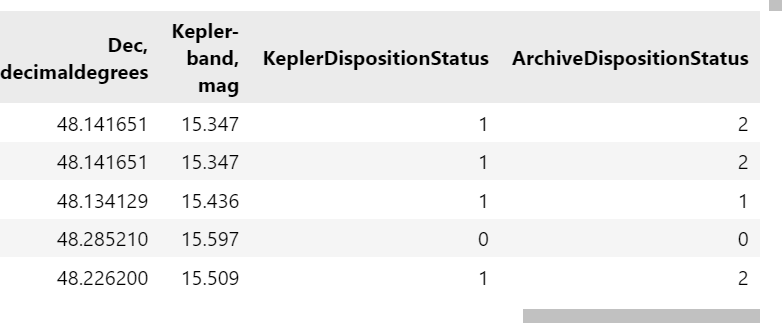

In [636]:
# remove irrelevant columns like names, id, etc. that won't be used for modeling
exoplanet_df = exoplanet_df.drop(columns=['KepID', 'KOIName', 'KeplerName', 'TCEDeliver'])

In [637]:
print("Shape before removing NaNs and infs:", exoplanet_df.shape)
# 1. Replace positive and negative infinite values with NaN
exoplanet_df = exoplanet_df.replace([np.inf, -np.inf], np.nan)

# 2. Drop all rows that contain any NaN/null values (which now includes the old infs)
exoplanet_df = exoplanet_df.dropna()

# Check how many rows are left
print("Shape after removing NaNs and infs:", exoplanet_df.shape)

Shape before removing NaNs and infs: (9563, 43)
Shape after removing NaNs and infs: (7802, 43)


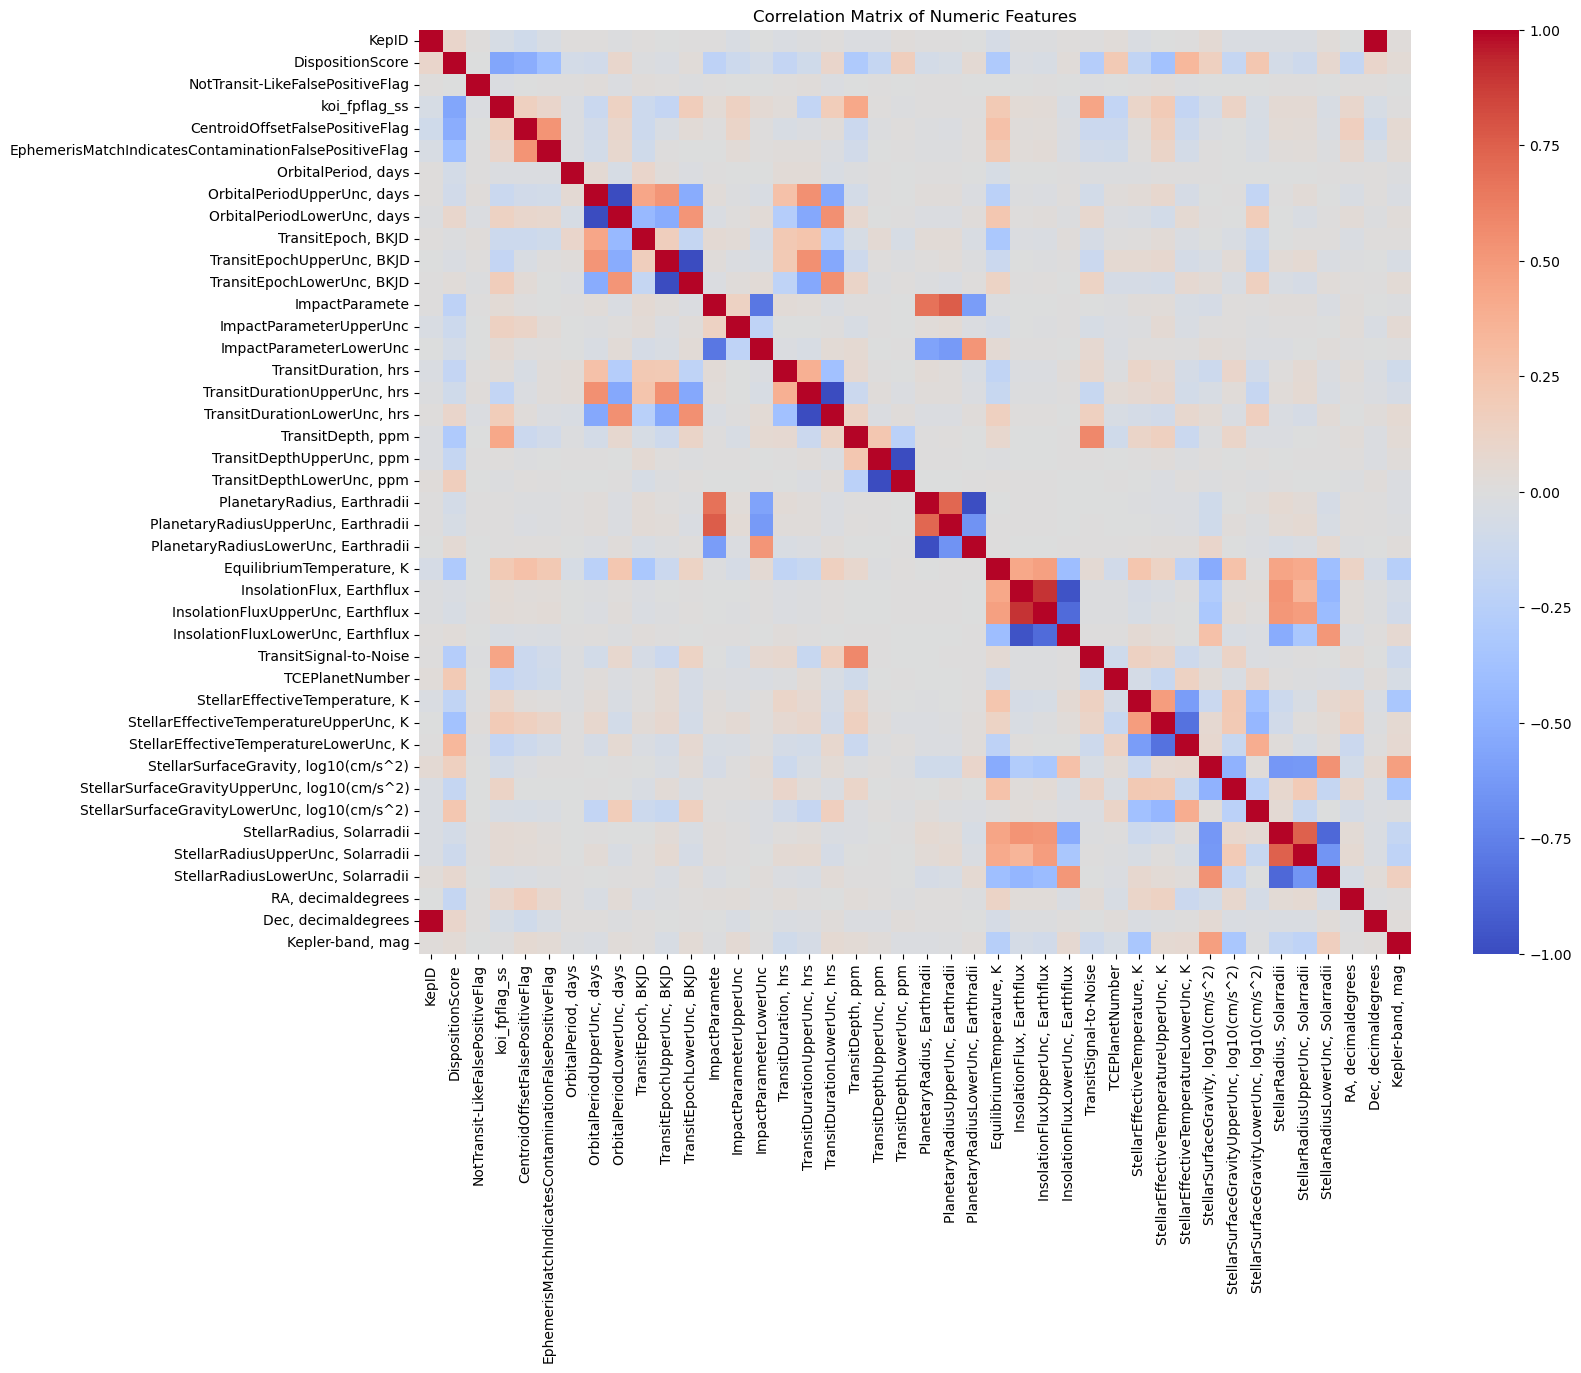

Highly correlated columns to drop: ['OrbitalPeriodLowerUnc, days', 'TransitEpochLowerUnc, BKJD', 'TransitDurationLowerUnc, hrs', 'TransitDepthLowerUnc, ppm', 'PlanetaryRadiusLowerUnc, Earthradii', 'InsolationFluxUpperUnc, Earthflux', 'InsolationFluxLowerUnc, Earthflux', 'Dec, decimaldegrees']
Shape after dropping highly correlated features: (7802, 35)


In [638]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the correlation matrix
corr_matrix = numeric_dataframe.corr()

# Plot the correlation matrix
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

# 4. Find highly correlated columns to drop (set threshold > 0.9)
# We find pairs of highly correlated features and drop one of them
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column].abs() > 0.9)]
print("Highly correlated columns to drop:", to_drop)

# Drop them from the original dataframe
exoplanet_df = exoplanet_df.drop(columns=to_drop)
print("Shape after dropping highly correlated features:", exoplanet_df.shape)

In [650]:
# Map for the categorical values
disposition_map = {'FALSE POSITIVE': 0, 'CANDIDATE': 1, 'CONFIRMED': 2}

# Try mapping the original categorical labels (Assuming their names are exactly these, or similar ones like koi_disposition/koi_pdisposition)
# Change the following strings if your column names differ slightly:
col1 = 'DispositionUsingKeplerData'
col2 = 'ExoplanetArchiveDisposition'

if col1 in exoplanet_df.columns and col2 in exoplanet_df.columns:
    # 1. Create two new features using the map
    exoplanet_df['KeplerDispositionStatus'] = exoplanet_df[col1].map(disposition_map)
    exoplanet_df['ArchiveDispositionStatus'] = exoplanet_df[col2].map(disposition_map)

    # 2. Drop the original features
    exoplanet_df = exoplanet_df.drop(columns=[col1, col2])
else:
    print(f"Columns NOT FOUND. Please update col1 and col2 with your actual dataframe column names.")

exoplanet_df.head(10)

Columns NOT FOUND. Please update col1 and col2 with your actual dataframe column names.


,DispositionScore,NotTransit-LikeFalsePositiveFlag,koi_fpflag_ss,CentroidOffsetFalsePositiveFlag,EphemerisMatchIndicatesContaminationFalsePositiveFlag,"OrbitalPeriod, days","OrbitalPeriodUpperUnc, days","TransitEpoch, BKJD","TransitEpochUpperUnc, BKJD",ImpactParamete,ImpactParameterUpperUnc,ImpactParameterLowerUnc,"TransitDuration, hrs","TransitDurationUpperUnc, hrs","TransitDepth, ppm","TransitDepthUpperUnc, ppm","PlanetaryRadius, Earthradii","PlanetaryRadiusUpperUnc, Earthradii","EquilibriumTemperature, K","InsolationFlux, Earthflux",TransitSignal-to-Noise,TCEPlanetNumber,"StellarEffectiveTemperature, K","StellarEffectiveTemperatureUpperUnc, K","StellarEffectiveTemperatureLowerUnc, K","StellarSurfaceGravity, log10(cm/s^2)","StellarSurfaceGravityUpperUnc, log10(cm/s^2)","StellarSurfaceGravityLowerUnc, log10(cm/s^2)","StellarRadius, Solarradii","StellarRadiusUpperUnc, Solarradii","StellarRadiusLowerUnc, Solarradii","RA, decimaldegrees","Kepler-band, mag",KeplerDispositionStatus,ArchiveDispositionStatus
0,1.000,0,0,0,0,2.350235,2.774961e-05,5.144809,0.002158,0.136278,0.276115,-0.136278,1.375613,0.078719,6.424545,3.020425,1.181727,0.231112,6.677083,4.549552,3.605498,0.693147,73.857972,9.000000,-4.406719,1.698730,0.062035,-0.309839,0.655964,0.099845,-0.059212,291.93423,3.917525,1,2
1,0.969,0,0,0,0,4.014911,2.478693e-04,5.096898,0.003514,0.461215,0.057325,-0.366724,1.706020,0.109751,6.775138,3.597312,1.342865,0.277632,6.095825,2.313525,3.288402,1.098612,73.857972,9.000000,-4.406719,1.698730,0.062035,-0.309839,0.655964,0.099845,-0.059212,291.93423,3.917525,1,2
2,0.000,0,0,0,0,3.039708,1.493989e-05,5.175303,0.000581,0.677526,1.812542,-0.074179,1.023242,0.033531,9.290075,5.147494,2.747271,1.593309,6.459904,3.696351,4.347694,0.693147,76.504902,12.569805,-5.176150,1.712716,0.043059,-0.419524,0.624868,0.209450,-0.075107,297.00482,3.928868,1,1
3,0.000,0,1,0,0,1.006845,2.630000e-07,5.143461,0.000115,0.822420,0.108854,-0.088011,1.225659,0.005356,8.997172,2.624669,3.539799,2.251292,7.241366,6.794542,6.227722,0.693147,76.190551,12.529964,-5.164786,1.716317,0.051643,-0.409878,0.582774,0.183155,-0.064851,285.53461,3.949304,0,0
4,1.000,0,0,0,0,1.260048,3.760993e-06,5.150951,0.001129,0.531216,0.211071,-0.390690,0.976256,0.041142,6.404071,2.884801,1.321756,0.631272,7.249215,6.832126,3.735286,0.693147,77.659513,13.000000,-5.356586,1.693411,0.067659,-0.458258,0.715887,0.288182,-0.124869,288.75488,3.938147,1,2
5,1.000,0,0,0,0,2.492736,2.035979e-05,5.148663,0.001409,0.430483,0.029559,-0.356275,1.721784,0.059212,7.325478,3.226844,1.589235,0.819780,6.728629,4.751951,4.212128,0.693147,77.756029,13.747727,-5.451038,1.702199,0.052592,-0.478539,0.679048,0.273837,-0.099845,296.28613,3.964089,1,2
6,1.000,0,0,0,0,1.635970,1.045995e-05,5.158937,0.001898,0.566450,0.130151,-0.426574,1.420744,0.065132,6.532334,2.980619,1.327075,0.641854,7.057037,6.060641,3.718438,1.098612,77.756029,13.747727,-5.451038,1.702199,0.052592,-0.478539,0.679048,0.273837,-0.099845,296.28613,3.964089,1,2
7,0.992,0,0,0,0,1.271610,1.780984e-05,5.196032,0.004599,0.562469,0.192272,-0.420682,1.232269,0.152721,5.427150,2.879198,0.951658,0.418710,7.215975,6.695477,2.772589,1.386294,77.756029,13.747727,-5.451038,1.702199,0.052592,-0.478539,0.679048,0.273837,-0.099845,296.28613,3.964089,1,2
8,0.000,0,1,1,0,2.123672,2.127977e-05,4.892231,0.002527,0.774266,2.095930,-0.043059,1.795419,0.127513,5.458308,1.916923,3.694116,2.008214,7.202661,6.644076,3.885679,0.693147,78.911343,10.535654,-4.828314,1.606634,0.167208,-0.313050,1.084513,0.279146,-0.394067,298.86435,3.558089,0,0
9,1.000,0,0,0,0,2.837243,1.087994e-05,5.162623,0.000517,0.050693,0.232698,-0.050693,1.511759,0.023814,8.500108,3.535145,1.911023,0.198851,6.398595,3.457893,5.093137,0.693147,70.929543,8.660254,-4.430817,1.702017,0.079735,-0.167332,0.614104,0.032467,-0.069526,286.99948,3.980075,1,2


#### Tasks continued
-  Consider whether some features should be transformed (e.g. using log, square root etc.) and do this if found relevant
-  Place `KeplerDispositionStatus` as the target and remove the following from the features: `DispositionScore`, `KeplerDispositionStatus`, `ArchiveDispositionStatus`
- Consider scaling your (numeric) data
- You should now have two datasets, one with cleaned features and one with the target labels (1 for Candidate and 0 otherwise)

In [640]:
# check the skewness again after drop highly correlated features and converting categorical to numeric
# Select only the numeric columns (ignores strings/objects)
numeric_dataframe = exoplanet_df.select_dtypes(include=[np.number])

# Keep columns where the unique values are NOT just 0 and/or 1
# also exclude the new numeric columns we just created for the categorical labels, 
# since they only have 3 unique values (0, 1, 2)
continuous_cols = [
    col for col in numeric_dataframe.columns 
    if not set(numeric_dataframe[col].unique()).issubset({0, 1, 2})
]

skew_values = exoplanet_df[continuous_cols].skew()
print(skew_values.sort_values(ascending=False))

PlanetaryRadiusUpperUnc, Earthradii             82.631286
PlanetaryRadius, Earthradii                     74.410310
InsolationFlux, Earthflux                       49.550937
TransitDepthUpperUnc, ppm                       28.312148
StellarRadiusUpperUnc, Solarradii               21.714305
StellarRadius, Solarradii                       19.722677
ImpactParamete                                  14.754008
TransitEpochUpperUnc, BKJD                      14.555475
OrbitalPeriodUpperUnc, days                     11.660009
TransitDurationUpperUnc, hrs                     9.175533
TransitDuration, hrs                             6.642410
ImpactParameterUpperUnc                          6.046365
TransitEpoch, BKJD                               5.103283
TransitSignal-to-Noise                           4.901024
TransitDepth, ppm                                4.599554
OrbitalPeriod, days                              4.005967
EquilibriumTemperature, K                        3.602748
TCEPlanetNumbe

In [641]:
# Create a dictionary to store the results
outlier_counts = {}

for col in continuous_cols:
    Q1 = exoplanet_df[col].quantile(0.25)
    Q3 = exoplanet_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count how many values fall outside the bounds
    # We use sum() because the condition returns booleans (True=1, False=0)
    outliers = ((exoplanet_df[col] < lower_bound) | (exoplanet_df[col] > upper_bound)).sum()
    
    outlier_counts[col] = outliers

# Convert to DataFrame for easy viewing
outlier_df = pd.DataFrame(list(outlier_counts.items()), columns=['Feature', 'Outlier_Count'])
outlier_df = outlier_df.sort_values(by='Outlier_Count', ascending=False)

# Display the result
outlier_df

,Feature,Outlier_Count
10,"TransitDepth, ppm",1599
16,TransitSignal-to-Noise,1383
13,"PlanetaryRadiusUpperUnc, Earthradii",1350
17,TCEPlanetNumber,1253
2,"OrbitalPeriodUpperUnc, days",1222
15,"InsolationFlux, Earthflux",1172
26,"StellarRadiusLowerUnc, Solarradii",1108
1,"OrbitalPeriod, days",1060
12,"PlanetaryRadius, Earthradii",1008
11,"TransitDepthUpperUnc, ppm",942


In [642]:
import numpy as np

# Create a copy so we don't accidentally mutate the dataframe multiple times if the cell is re-run
transformed_df = exoplanet_df.copy()

# create a function to apply the mathematically appropriate transformation based on skewness
def transform_by_skewness(series):
    skewness = series.skew()
    
    # Highly skewed (both pos and neg)
    if abs(skewness) > 1.0:
        # We use a signed log-transformation to safely handle negative values and zeros
        # np.log1p(x) calculates log(1 + x)
        return np.sign(series) * np.log1p(np.abs(series))
        
    # Moderately skewed (both pos and neg)
    elif 0.5 < abs(skewness) <= 1.0:
        # We use a signed square root to softly compress the tail
        return np.sign(series) * np.sqrt(np.abs(series))
        
    # Approximately symmetric (low skew)
    else:
        # No transformation needed
        return series

# Apply the transformation to our continuous columns
for col in continuous_cols:
    transformed_df[col] = transform_by_skewness(transformed_df[col])

# Re-assign to our main dataframe
exoplanet_df = transformed_df

# Check the new skewness distribution to see how much it improved
new_skew_values = exoplanet_df[continuous_cols].skew()
print("Skewness after mathematical transformations:\n")
print(new_skew_values.sort_values(ascending=False))

Skewness after mathematical transformations:

TransitEpochUpperUnc, BKJD                      12.514140
OrbitalPeriodUpperUnc, days                     11.176711
StellarRadiusUpperUnc, Solarradii                5.205910
StellarRadius, Solarradii                        4.357411
ImpactParameterUpperUnc                          3.840666
TransitDurationUpperUnc, hrs                     3.286190
StellarEffectiveTemperatureLowerUnc, K           2.949222
TransitEpoch, BKJD                               2.740084
TCEPlanetNumber                                  2.636336
StellarSurfaceGravityUpperUnc, log10(cm/s^2)     2.439845
PlanetaryRadiusUpperUnc, Earthradii              1.565964
TransitSignal-to-Noise                           1.219972
PlanetaryRadius, Earthradii                      1.137017
TransitDepth, ppm                                1.072526
TransitDuration, hrs                             0.937276
ImpactParamete                                   0.873468
TransitDepthUpperUnc, ppm 

Text(0.5, 1.0, 'StellarSurfaceGravityLowerUnc')

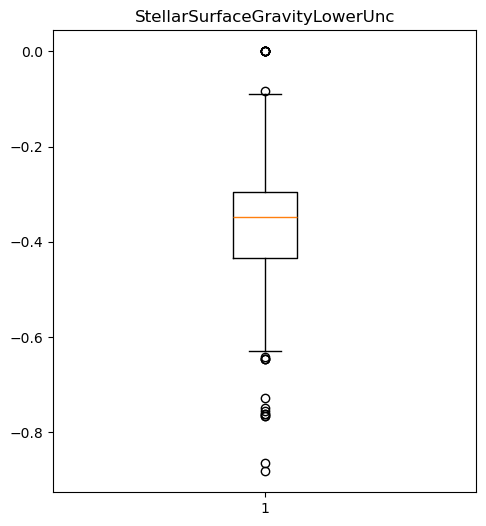

In [643]:
# just for visualization, we can plot the boxplot for the column with the highest outlier count to see how it looks like
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.boxplot(exoplanet_df['StellarSurfaceGravityLowerUnc, log10(cm/s^2)'].dropna())
plt.title('StellarSurfaceGravityLowerUnc')

Text(0.5, 1.0, 'TransitEpochUpperUnc')

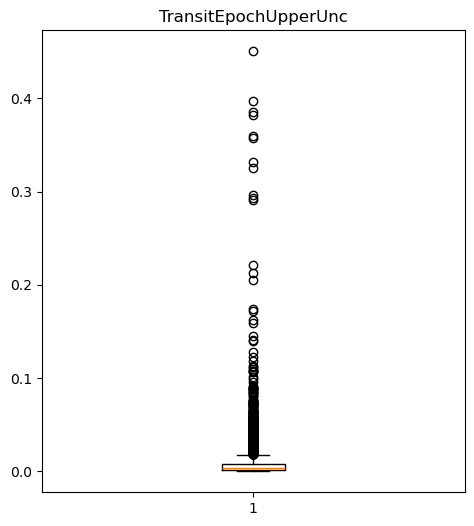

In [644]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.boxplot(exoplanet_df['TransitEpochUpperUnc, BKJD'].dropna())
plt.title('TransitEpochUpperUnc')

Since skewness value the still very high (12.5), so we can try to use `RobustScaler` to scale the data, which is less sensitive to outliers than `StandardScaler`.

In [645]:
from sklearn.preprocessing import RobustScaler

# 1. Separate the target (y) and features (X)
# We place KeplerDispositionStatus as the target
y = exoplanet_df['KeplerDispositionStatus']

# Remove the target and unwanted columns from the features
cols_to_drop = [
    'DispositionScore', 
    'KeplerDispositionStatus', 
    'ArchiveDispositionStatus',
    'NotTransit-LikeFalsePositiveFlag',
    'koi_fpflag_ss',
    'CentroidOffsetFalsePositiveFlag',
    'EphemerisMatchIndicatesContaminationFalsePositiveFlag'
]
# Only drop columns that actually exist in the dataframe to avoid errors
existing_cols_to_drop = [col for col in cols_to_drop if col in exoplanet_df.columns]

X = exoplanet_df.drop(columns=existing_cols_to_drop)

# 2. Scale the features
# We scale only the continuous numeric features, leaving binary flags untouched
scaler = RobustScaler()

X_scaled = X.copy()
# Find the columns in X that need scaling (continuous columns present in X)
cols_to_scale = [col for col in continuous_cols if col in X.columns]

X_scaled[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

# X_scaled is now your final, clean feature dataset
print("Shape of X_scaled:", X_scaled.shape)
print("Shape of y:", y.shape)


Shape of X_scaled: (7802, 28)
Shape of y: (7802,)


### 3. Train, Test, Validation
- Consider whether to use cross validation or not
-  Consider which method to use to split the data and do the appropriate splits - if using CV still make a test set

We split the data into a **training set (80%)** and a **test set (20%)**. The test set is held out entirely and only used for final evaluation in Task 5 — it never influences training or tuning.

For **hyperparameter tuning** in Task 4, we use `GridSearchCV` with **5-fold Stratified Cross-Validation** on the training set. This gives a reliable generalisation estimate without touching the test set.

`stratify=y` ensures each split preserves the original class ratio (~50 % CANDIDATE, ~50 % FALSE POSITIVE), which is important for classification.

In [646]:
from sklearn.model_selection import train_test_split

# 80% training, 20% test
# stratify=y preserves the class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X_scaled)*100:.1f}%)')
print(f'Test set     : {X_test.shape[0]} samples ({X_test.shape[0]/len(X_scaled)*100:.1f}%)')
print('')
print('Class distribution — Training:')
print(y_train.value_counts().rename({0: 'FALSE POSITIVE', 1: 'CANDIDATE'}))
print('')
print('Class distribution — Test:')
print(y_test.value_counts().rename({0: 'FALSE POSITIVE', 1: 'CANDIDATE'}))

Training set : 6241 samples (80.0%)
Test set     : 1561 samples (20.0%)

Class distribution — Training:
KeplerDispositionStatus
CANDIDATE         3248
FALSE POSITIVE    2993
Name: count, dtype: int64

Class distribution — Test:
KeplerDispositionStatus
CANDIDATE         813
FALSE POSITIVE    748
Name: count, dtype: int64


### 4. Models and Fine Tuning
- Use classification algorithms to train 2 classification models:
    1. Logistic Regression
    2. Support Vector Machine
- Fine tune the models either manually or using grid or random search

In [647]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 5-fold stratified CV preserves class balance across folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -- 1. Logistic Regression --
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # liblinear supports both l1 and l2
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=lr_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
lr_grid.fit(X_train, y_train)

best_lr = lr_grid.best_estimator_
print('Logistic Regression')
print(f'  Best params : {lr_grid.best_params_}')
print(f'  Best CV F1  : {lr_grid.best_score_:.4f}')

# -- 2. Support Vector Machine --
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    SVC(random_state=42),
    param_grid=svm_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_
print('')
print('Support Vector Machine')
print(f'  Best params : {svm_grid.best_params_}')
print(f'  Best CV F1  : {svm_grid.best_score_:.4f}')

Logistic Regression
  Best params : {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
  Best CV F1  : 0.8730

Support Vector Machine
  Best params : {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
  Best CV F1  : 0.8835


### 5. Evaluate
- Display the confusion matrix for both models
- Evaluate the models using accuracy, precision, recall, and f1-score

We evaluate each fine-tuned model on the **held-out test set**.

**Confusion Matrix** — rows = actual class, columns = predicted class:
- **True Positive (TP)**: predicted CANDIDATE, actually CANDIDATE = yes
- **True Negative (TN)**: predicted FALSE POSITIVE, actually FALSE POSITIVE = yes
- **False Positive (FP)**: predicted CANDIDATE, actually FALSE POSITIVE → wastes telescope follow-up time
- **False Negative (FN)**: predicted FALSE POSITIVE, actually CANDIDATE → a real exoplanet candidate is missed

**Metrics:**
- **Accuracy** = (TP + TN) / N — overall correctness
- **Precision** = TP / (TP + FP) — of all predicted CANDIDATEs, how many are real
- **Recall** = TP / (TP + FN) — of all real CANDIDATEs, how many were found
- **F1-score** = 2 × Precision × Recall / (Precision + Recall) — harmonic mean, balances both concerns

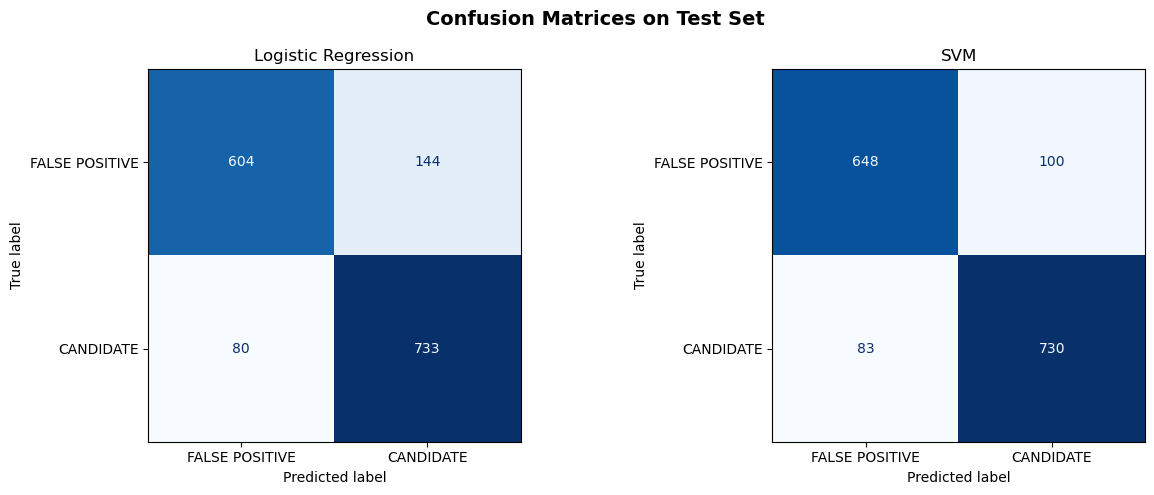

  Logistic Regression
                precision    recall  f1-score   support

FALSE POSITIVE       0.88      0.81      0.84       748
     CANDIDATE       0.84      0.90      0.87       813

      accuracy                           0.86      1561
     macro avg       0.86      0.85      0.86      1561
  weighted avg       0.86      0.86      0.86      1561

  SVM
                precision    recall  f1-score   support

FALSE POSITIVE       0.89      0.87      0.88       748
     CANDIDATE       0.88      0.90      0.89       813

      accuracy                           0.88      1561
     macro avg       0.88      0.88      0.88      1561
  weighted avg       0.88      0.88      0.88      1561



In [648]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

class_names = ['FALSE POSITIVE', 'CANDIDATE']

# -- Confusion Matrices --
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrices on Test Set', fontsize=14, fontweight='bold')

for ax, model, name in zip(
    axes,
    [best_lr, best_svm],
    ['Logistic Regression', 'SVM']
):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)

plt.tight_layout()
plt.show()

# -- Classification Reports --
sep = '=' * 52
for model, name in zip([best_lr, best_svm], ['Logistic Regression', 'SVM']):
    y_pred = model.predict(X_test)
    print(sep)
    print(f'  {name}')
    print(sep)
    print(classification_report(y_test, y_pred, target_names=class_names))